# Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import SelectKBest, mutual_info_regression

In [2]:
TICKER = 'TSLA' # Change it to the Ticker you want to save
DATA_DIR = '../data/features'
OUTPUT_DIR = '../data/selected'

# Load Stock Data X and y 

In [3]:
stocks = pd.read_csv(f"{DATA_DIR}/complete_features.csv")

In [4]:
"""
Create final feature matrix (X) and target vector (y) for each stock.

Args:
    df: DataFrame with all features
    use_scaled: Whether to use scaled features (default True)

Returns:
    Dictionary with stock symbols as keys, containing X, y, and dates
"""
def create_feature_matrix(df, use_scaled=True):
    # Identify feature columns
    exclude_cols = ['date', 'symbol', 'next_day_return']
    
    if use_scaled:
        # Use only scaled features
        feature_cols = [col for col in df.columns if col.endswith('_scaled')]
    else:
        # Use original features
        feature_cols = [col for col in df.columns if col not in exclude_cols and not col.endswith('_scaled')]
    
    # Target variable
    target_col = 'next_day_return'
    
    stock_data = {}
    
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Remove rows with missing target or features
        valid_mask = (
            stock_df[target_col].notnull() & 
            stock_df[feature_cols].notnull().all(axis=1)
        )
        
        stock_df_clean = stock_df[valid_mask].copy()
        
        # Create X and y
        X = stock_df_clean[feature_cols]
        y = stock_df_clean[[target_col]]
        dates = pd.to_datetime(stock_df_clean['date'])
        
        stock_data[symbol] = {
            'X': X,
            'y': y,
            'dates': dates,
            'feature_names': feature_cols,
            'n_samples': len(X),
            'n_features': len(feature_cols)
        }
    
    return stock_data

In [5]:
# create feature matrices X and y
feature_matrices = create_feature_matrix(df=stocks)

In [6]:
# Investigate a particular ticker
feature_matrices[TICKER]['X']

,open_scaled,high_scaled,low_scaled,close_scaled,volume_scaled,log_return_scaled,return_lag_1_scaled,return_lag_2_scaled,return_lag_3_scaled,return_lag_5_scaled,...,volume_ratio_10_scaled,avg_volume_20_scaled,volume_ratio_20_scaled,vwap_5_scaled,price_to_vwap_scaled,obv_scaled,obv_ema_scaled,daily_range_scaled,close_to_high_scaled,close_to_low_scaled
8556,-0.720764,-0.720314,-0.720761,-0.716788,-0.352614,-0.264345,1.167175,0.222527,-0.164673,-0.213542,...,1.172553,-0.376524,-0.071169,-0.719789,0.270871,-0.825013,-0.819176,-0.492189,0.214799,-0.536276
8557,-0.719186,-0.718954,-0.719324,-0.714944,0.070023,0.589063,-0.264345,1.168072,0.222704,-0.241009,...,2.051050,-0.345043,0.688191,-0.718668,0.478335,-0.817002,-0.818144,-0.517171,-0.070921,-0.281611
8558,-0.718718,-0.719075,-0.718682,-0.715105,-0.078887,-0.091450,0.589063,-0.264548,1.168428,-0.162402,...,1.284747,-0.353399,0.419180,-0.717926,0.213302,-0.824300,-0.818623,-0.905710,-0.047583,-0.737984
8559,-0.719712,-0.719298,-0.719396,-0.714982,-0.755332,0.003665,-0.091450,0.589516,-0.264462,0.225096,...,-0.536407,-0.391488,-0.836321,-0.717441,0.108313,-0.820241,-0.818279,-0.660178,-0.252394,-0.262482
8560,-0.719060,-0.719226,-0.721970,-0.718262,0.017563,-1.163288,0.003665,-0.091520,0.589764,1.171118,...,1.226150,-0.373734,0.640424,-0.717932,-0.696823,-0.828000,-0.819406,0.738563,1.724944,-0.711206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10690,0.741301,0.735477,0.760277,0.730700,-0.475244,0.023062,0.004675,-0.364691,0.880185,0.331327,...,0.115680,-0.659673,0.128312,0.732163,-0.006914,0.489594,0.482450,-0.368822,0.386864,-0.570174
10691,0.739635,0.789855,0.767162,0.822694,0.019550,1.468634,0.023062,0.004679,-0.364624,0.304169,...,1.183327,-0.625163,1.188232,0.761792,0.871030,0.497363,0.485420,0.868640,-0.683293,1.890938
10692,0.830713,0.908833,0.869042,0.941428,1.026840,1.784286,1.468634,0.023080,0.004816,0.882784,...,2.908975,-0.535657,3.126140,0.830866,1.504557,0.509954,0.490135,1.252966,-0.619351,2.259615
10693,1.059572,1.033439,1.013898,1.003137,0.959072,0.860586,1.784286,1.469764,0.023220,-0.362417,...,2.280659,-0.449659,2.691750,0.896710,1.394234,0.522220,0.496220,0.724579,0.971198,0.041942


# Feature Selection
## Step 1: Drop relatively low-variance columns

In [7]:
X = feature_matrices[TICKER]['X']
variances = X.var()
feature_cols = feature_matrices[TICKER]['feature_names']

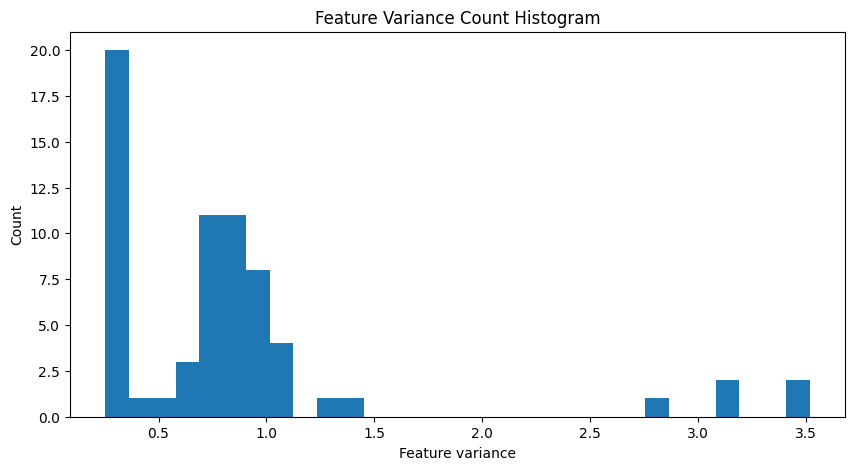

In [8]:
# Visualize variance distribution
plt.figure(figsize=(10,5))
plt.hist(variances, bins=30)
plt.title("Feature Variance Count Histogram")
plt.xlabel("Feature variance")
plt.ylabel("Count")
plt.show()

In [9]:
# Drop bottom 25% of the variance
T = np.percentile(variances, 25) 
selector = VarianceThreshold(threshold=T)
X_cleaned = selector.fit_transform(X)
X_cleaned.shape

(2139, 49)

In [10]:
# Boolean mask of kept features
support_mask = selector.get_support()

# Features that were kept
kept_features = [f for f, keep in zip(feature_cols, support_mask) if keep]

# Features that were dropped
dropped_features = [f for f, keep in zip(feature_cols, support_mask) if not keep]

# Update feature matrices
feature_matrices[TICKER]['X'] = pd.DataFrame(X_cleaned, columns=kept_features)
feature_matrices[TICKER]['feature_names'] = kept_features
feature_matrices[TICKER]['n_features'] = X_cleaned.shape[1]

In [11]:
# Reinvestigate that particular ticker
feature_matrices[TICKER]['X']

,high_scaled,volume_scaled,log_return_scaled,return_lag_1_scaled,return_lag_2_scaled,return_lag_3_scaled,return_lag_5_scaled,return_lag_10_scaled,return_lag_20_scaled,price_ratio_5_scaled,...,avg_volume_5_scaled,volume_ratio_5_scaled,avg_volume_10_scaled,volume_ratio_10_scaled,avg_volume_20_scaled,volume_ratio_20_scaled,price_to_vwap_scaled,daily_range_scaled,close_to_high_scaled,close_to_low_scaled
0,-0.720314,-0.352614,-0.264345,1.167175,0.222527,-0.164673,-0.213542,-0.031530,-0.000020,0.295954,...,-0.638219,0.663671,-0.803103,1.172553,-0.376524,-0.071169,0.270871,-0.492189,0.214799,-0.536276
1,-0.718954,0.070023,0.589063,-0.264345,1.168072,0.222704,-0.241009,0.012664,-0.146127,0.636690,...,-0.464269,1.324832,-0.703280,2.051050,-0.345043,0.688191,0.478335,-0.517171,-0.070921,-0.281611
2,-0.719075,-0.078887,-0.091450,0.589063,-0.264548,1.168428,-0.162402,0.077062,-1.043952,0.667193,...,-0.280784,0.445665,-0.608799,1.284747,-0.353399,0.419180,0.213302,-0.905710,-0.047583,-0.737984
3,-0.719298,-0.755332,0.003665,-0.091450,0.589516,-0.264462,0.225096,-0.071446,0.275779,0.576323,...,-0.249142,-1.208008,-0.601966,-0.536407,-0.391488,-0.836321,0.108313,-0.660178,-0.252394,-0.262482
4,-0.719226,0.017563,-1.163288,0.003665,-0.091520,0.589764,1.171118,-0.304262,0.446235,-0.345431,...,-0.286030,0.688664,-0.510891,1.226150,-0.373734,0.640424,-0.696823,0.738563,1.724944,-0.711206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,0.735477,-0.475244,0.023062,0.004675,-0.364691,0.880185,0.331327,0.338875,0.101690,0.347031,...,-0.540588,0.028878,-0.562096,0.115680,-0.659673,0.128312,-0.006914,-0.368822,0.386864,-0.570174
2135,0.789855,0.019550,1.468634,0.023062,0.004679,-0.364624,0.304169,-0.186450,-0.144624,0.830489,...,-0.387131,0.959614,-0.494786,1.183327,-0.625163,1.188232,0.871030,0.868640,-0.683293,1.890938
2136,0.908833,1.026840,1.784286,1.468634,0.023080,0.004816,0.882784,-0.302316,-0.323071,1.220771,...,-0.176200,2.694764,-0.318305,2.908975,-0.535657,3.126140,1.504557,1.252966,-0.619351,2.259615
2137,1.033439,0.959072,0.860586,1.784286,1.469764,0.023220,-0.362417,-0.950968,-0.420705,1.771410,...,0.139716,1.638333,-0.172762,2.280659,-0.449659,2.691750,1.394234,0.724579,0.971198,0.041942


## Step 2: Drop multicollinear columns

In [12]:
X = feature_matrices[TICKER]['X']

In [13]:
# Calculate variance inflation factors (higher VIF = stronger multicolinearity)
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [14]:
vif.head(10)

,feature,VIF
0,high_scaled,533.628021
1,volume_scaled,19.038906
2,log_return_scaled,724.618400
3,return_lag_1_scaled,410.918552
4,return_lag_2_scaled,179.791761
5,return_lag_3_scaled,47.003004
6,return_lag_5_scaled,2.541644
7,return_lag_10_scaled,1.552829
8,return_lag_20_scaled,1.158413
9,price_ratio_5_scaled,inf


In [15]:
# Create a boolean mask for infinite VIF
# This is what we are going to drop eventually
drop_mask = np.isinf(vif["VIF"])

# Identify which features to drop
dropped_features = vif.loc[drop_mask, "feature"].tolist()
kept_features = vif.loc[~drop_mask, "feature"].tolist()

# Update feature matrices
feature_matrices[TICKER]['X'] = pd.DataFrame(X, columns=kept_features)
feature_matrices[TICKER]['feature_names'] = kept_features
feature_matrices[TICKER]['n_features'] = X.shape[1]

In [16]:
# Reinvestigate that particular ticker
feature_matrices[TICKER]['X']

,high_scaled,volume_scaled,log_return_scaled,return_lag_1_scaled,return_lag_2_scaled,return_lag_3_scaled,return_lag_5_scaled,return_lag_10_scaled,return_lag_20_scaled,price_ratio_20_scaled,...,avg_volume_5_scaled,volume_ratio_5_scaled,avg_volume_10_scaled,volume_ratio_10_scaled,avg_volume_20_scaled,volume_ratio_20_scaled,price_to_vwap_scaled,daily_range_scaled,close_to_high_scaled,close_to_low_scaled
0,-0.720314,-0.352614,-0.264345,1.167175,0.222527,-0.164673,-0.213542,-0.031530,-0.000020,-0.504171,...,-0.638219,0.663671,-0.803103,1.172553,-0.376524,-0.071169,0.270871,-0.492189,0.214799,-0.536276
1,-0.718954,0.070023,0.589063,-0.264345,1.168072,0.222704,-0.241009,0.012664,-0.146127,-0.382990,...,-0.464269,1.324832,-0.703280,2.051050,-0.345043,0.688191,0.478335,-0.517171,-0.070921,-0.281611
2,-0.719075,-0.078887,-0.091450,0.589063,-0.264548,1.168428,-0.162402,0.077062,-1.043952,-0.220545,...,-0.280784,0.445665,-0.608799,1.284747,-0.353399,0.419180,0.213302,-0.905710,-0.047583,-0.737984
3,-0.719298,-0.755332,0.003665,-0.091450,0.589516,-0.264462,0.225096,-0.071446,0.275779,-0.266955,...,-0.249142,-1.208008,-0.601966,-0.536407,-0.391488,-0.836321,0.108313,-0.660178,-0.252394,-0.262482
4,-0.719226,0.017563,-1.163288,0.003665,-0.091520,0.589764,1.171118,-0.304262,0.446235,-0.533492,...,-0.286030,0.688664,-0.510891,1.226150,-0.373734,0.640424,-0.696823,0.738563,1.724944,-0.711206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,0.735477,-0.475244,0.023062,0.004675,-0.364691,0.880185,0.331327,0.338875,0.101690,-0.001125,...,-0.540588,0.028878,-0.562096,0.115680,-0.659673,0.128312,-0.006914,-0.368822,0.386864,-0.570174
2135,0.789855,0.019550,1.468634,0.023062,0.004679,-0.364624,0.304169,-0.186450,-0.144624,0.301493,...,-0.387131,0.959614,-0.494786,1.183327,-0.625163,1.188232,0.871030,0.868640,-0.683293,1.890938
2136,0.908833,1.026840,1.784286,1.468634,0.023080,0.004816,0.882784,-0.302316,-0.323071,0.726501,...,-0.176200,2.694764,-0.318305,2.908975,-0.535657,3.126140,1.504557,1.252966,-0.619351,2.259615
2137,1.033439,0.959072,0.860586,1.784286,1.469764,0.023220,-0.362417,-0.950968,-0.420705,1.002869,...,0.139716,1.638333,-0.172762,2.280659,-0.449659,2.691750,1.394234,0.724579,0.971198,0.041942


## Step 3: SelectKBest

In [17]:
X = feature_matrices[TICKER]['X']
y = feature_matrices[TICKER]['y']
dates = feature_matrices[TICKER]['dates']
feature_cols = feature_matrices[TICKER]['feature_names']

In [18]:
selector = SelectKBest(mutual_info_regression, k=20)
X_cleaned = selector.fit_transform(X, np.ravel(y))

In [19]:
# Reconstruct columns
support_mask = selector.get_support()
kept_features    = list(np.array(feature_cols)[support_mask])
dropped_features = list(np.array(feature_cols)[~support_mask])
X_cleaned = pd.DataFrame(X[kept_features], columns=kept_features)
# Update feature matrices
feature_matrices[TICKER]['X'] = pd.DataFrame(X_cleaned, columns=kept_features)
feature_matrices[TICKER]['feature_names'] = kept_features
feature_matrices[TICKER]['n_features'] = X_cleaned.shape[1]

In [20]:
# Reinvestigate final feature matrix
X_final = feature_matrices[TICKER]['X']
X_final.index = dates

# Save X,y as npy files
## It is feature-selected and now ready for training!

In [21]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
X_final.to_csv(f"{OUTPUT_DIR}/{TICKER}_X.csv", index=True)
y.to_csv(f"{OUTPUT_DIR}/{TICKER}_y.csv", index=False)